## Palmer's Penguins Project

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

| Column            | Description         |
|-------------------|---------------------|
| culmen_length_mm  | culmen length (mm)  |
| culmen_depth_mm   | culmen depth (mm)   |
| flipper_length_mm | flipper length (mm) |
| body_mass_g       | body mass (g)       |
| sex               | penguin sex         |

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

#### Plan

1. Clean data

2. Convert to numbers

3. Scale

4. Cluster

5. Summarise

In [8]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
# Resolve data file relative to this notebook, with fallback to project-wide search.
base_dir = Path.cwd()
candidate_paths = [
    base_dir / "inst" / "extdata" / "penguins.csv",
    base_dir / "data" / "penguins.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    matches = sorted(base_dir.rglob("*penguins*.csv"))
    if not matches:
        raise FileNotFoundError("Could not find a penguins CSV file in this project.")
    csv_path = matches[0]

penguins_df = pd.read_csv(csv_path)
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [9]:
penguins_encoded = pd.get_dummies(penguins_df, drop_first=True)

penguins_numeric = penguins_encoded.select_dtypes(include=['number']).copy()

# KMeans cannot handle NaN values, so impute numeric missing values with column medians.
penguins_for_cluster = penguins_numeric.fillna(penguins_numeric.median(numeric_only=True))
if penguins_for_cluster.isna().any().any():
    raise ValueError("NaN values remain after imputation. Check source data columns.")

scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_for_cluster)

inertia = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(penguins_scaled)
    inertia.append(kmeans.inertia_)

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(penguins_scaled)

penguins_for_cluster['cluster'] = kmeans.labels_

stat_penguins = penguins_for_cluster.groupby('cluster').mean()
stat_penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
cluster,,,,,
0,40.747951,18.036066,192.614754,3662.500000,2008.631148
1,47.504878,14.982114,217.186992,5076.016260,2008.073171
2,43.392424,18.758586,190.848485,3777.020202,2007.232323


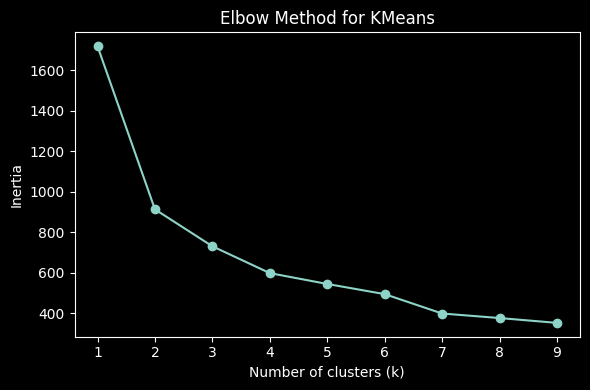

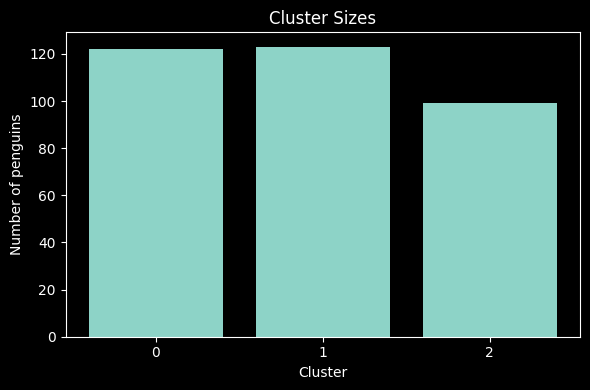

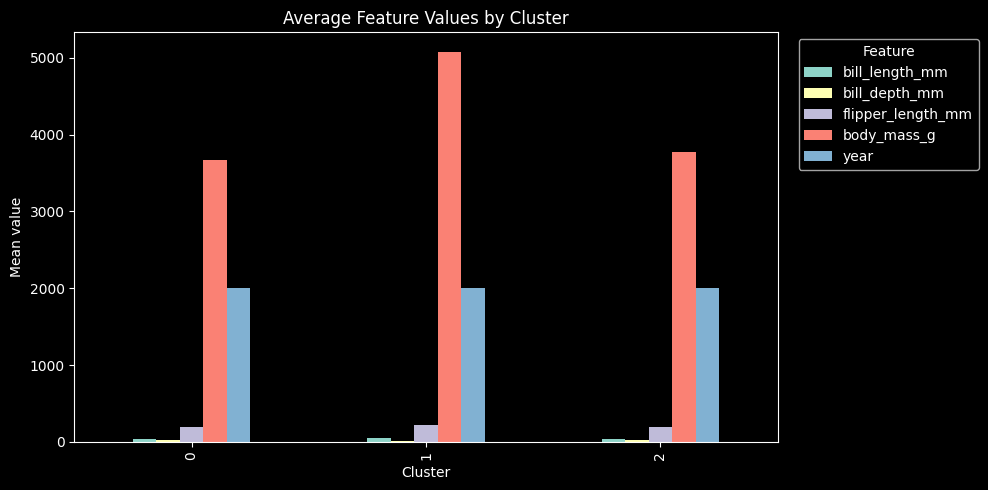

In [10]:
# Visualize clustering results

# 1) Elbow curve to inspect the best number of clusters
plt.figure(figsize=(6, 4))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.xticks(range(1, 10))
plt.tight_layout()
plt.show()

# 2) Cluster sizes
cluster_sizes = penguins_for_cluster['cluster'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel('Cluster')
plt.ylabel('Number of penguins')
plt.title('Cluster Sizes')
plt.tight_layout()
plt.show()

# 3) Mean feature values by cluster
stat_penguins.plot(kind='bar', figsize=(10, 5))
plt.title('Average Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean value')
plt.legend(title='Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
